# Trabajo Práctico 2 (TP2) - Parte 2: Regresión Logística, Curva de Aprendizaje y Evaluación de Desempeño

### Machine Learning 1 (23433)
#### Facultad de Ingeniería - Universidad Nacional de Asunción (FIUNA)

---

## Objetivos de la Parte 2
1. Configurar una partición estratificada Train/Test (80% Train, 20% Test sobre 64,295 muestras) previniendo el fuga de datos (*data leakage*).
2. Diseñar un `ColumnTransformer` profesional con `SimpleImputer`, `PolynomialFeatures(degree=2)`, `StandardScaler` y `OneHotEncoder`.
3. Entrenar un modelo de `LogisticRegression(class_weight='balanced')` con optimización de hiperparámetros vía `GridSearchCV`.
4. Calcular y graficar la **Curva de Aprendizaje (`learning_curve`)** evaluando la convergencia en validación cruzada.
5. Optimizar el umbral de decisión ($	au^*$) e inspeccionar la Matriz de Confusión, Curva ROC (AUC) y Curva Precision-Recall.


In [1]:
# 1. Carga de Librerías y Dataset del TP2
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Carga del Dataset del TP2
csv_path = 'reglamento_nuevo_unificado.csv'
df_raw = pd.read_csv(csv_path)
print(f"Dataset del TP2 cargado exitosamente: {df_raw.shape[0]:,} filas.")
df_clean = pd.read_pickle("df_clean.pkl")


Dataset del TP2 cargado exitosamente: 64,295 filas.


## Ejercicio 1: Partición Estratificada Train / Test

Define las listas de atributos numéricos `num_features` y categóricos `cat_features`.
Realiza una partición estratificada del 80% para entrenamiento (`X_train`) y 20% para prueba (`X_test`).


In [4]:
# TODO: Definir num_features, cat_features y particionar X e y
# === ESCRIBE TU CÓDIGO AQUÍ ===
num_features = ['Primer_Par_Clean', 'Segundo_Par_Clean', 'Score_Parciales', 'Diff_Parciales', 'TPLab_Clean', 'Firma_Clean', 'FirmaCalc_Clean', 'Asis_Clean']
cat_features = ['Carrera_Nombre', 'Semestre']
X = df_clean[num_features + cat_features]
y = df_clean['Target']
# Suponiendo df_clean cargado del notebook anterior
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(f"Train: {len(X_train):,}")
print(f"Test: {len(X_test):,}")

Train: 51,436
Test: 12,859


## Ejercicio 2: Construcción del Preprocesador Profesional (`ColumnTransformer`)

Construye un `Pipeline` numérico con:
1. `SimpleImputer(strategy='median')`
2. `PolynomialFeatures(degree=2, include_bias=False)`
3. `StandardScaler()`

Y un `Pipeline` categórico con `SimpleImputer` y `OneHotEncoder(handle_unknown='ignore')`.


In [5]:
# TODO: Ensamblar num_transformer, cat_transformer y preprocessor
# === ESCRIBE TU CÓDIGO AQUÍ ===
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

print("Preprocesador creado exitosamente!")


Preprocesador creado exitosamente!


## Ejercicio 3: Entrenamiento del Modelo y Búsqueda en Malla (`GridSearchCV`)

Ensambla `full_pipeline` con `LogisticRegression(class_weight='balanced', solver='lbfgs', max_iter=2000)`.
Configura `GridSearchCV` sobre el parámetro de regularización `C` en `[0.01, 0.1, 1.0, 10.0]` con `scoring='f1'`.


In [12]:
# TODO: Instanciar full_pipeline y GridSearchCV
# === ESCRIBE TU CÓDIGO AQUÍ ===
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='lbfgs', max_iter=2000, random_state=42, class_weight='balanced'))
])

param_grid = {'classifier__C': [0.01, 0.1, 1.0, 10.0]}
grid_search = GridSearchCV(full_pipeline, param_grid, cv=StratifiedKFold(n_splits=5), scoring='f1', n_jobs=1)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
print("Mejores parametros:", grid_search.best_params_)
print(f"Mejor CV F1: {grid_search.best_score_:.4f}")


Mejores parametros: {'classifier__C': 0.1}
Mejor CV F1: 0.8835


## Ejercicio 4: Graficación de la Curva de Aprendizaje (`learning_curve`)

Calcula y grafica la curva de aprendizaje utilizando `learning_curve` sobre `X_train` y `y_train` con 10 tamaños de entrenamiento (`np.linspace(0.1, 1.0, 10)`).


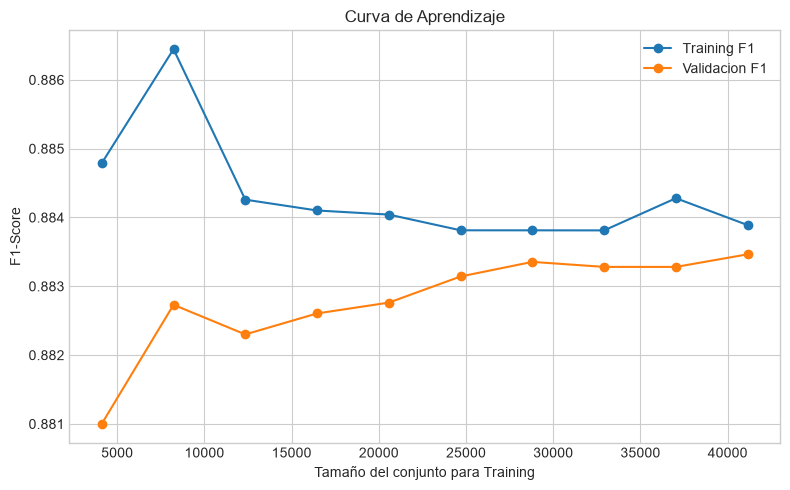

In [14]:
# TODO: Calcular y graficar la Curva de Aprendizaje (Learning Curve)
# === ESCRIBE TU CÓDIGO AQUÍ ===
train_sizes, train_scores, val_scores = learning_curve(
     best_model, X_train, y_train, cv=StratifiedKFold(n_splits=5),
     scoring='f1', train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=1
 )

train_mean = train_scores.mean(axis = 1)
val_mean = val_scores.mean(axis = 1)

plt.figure(figsize = (8,5))

plt.plot(train_sizes, train_mean, marker = 'o', label = 'Training F1')
plt.plot(train_sizes, val_mean, marker = 'o', label = 'Validacion F1')

plt.xlabel('Tamaño del conjunto para Training')
plt.ylabel('F1-Score')
plt.title('Curva de Aprendizaje')
plt.legend()
plt.tight_layout()
plt.show()


## Ejercicio 5: Optimización del Umbral de Decisión y Evaluación de Desempeño

En el conjunto de prueba (`X_test`):
1. Obtén las probabilidades de aprobación `y_proba_test`.
2. Optimiza el umbral de decisión ($	au^*$) entre `0.1` y `0.9` que maximiza el F1-Score.
3. Grafica la **Matriz de Confusión**, la **Curva ROC (AUC)** y la **Curva Precision-Recall**.


Threshold: 0.40 | F1: 0.6421 | AUC: 0.9334


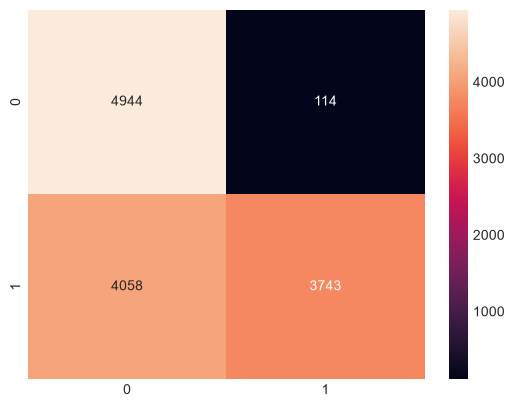

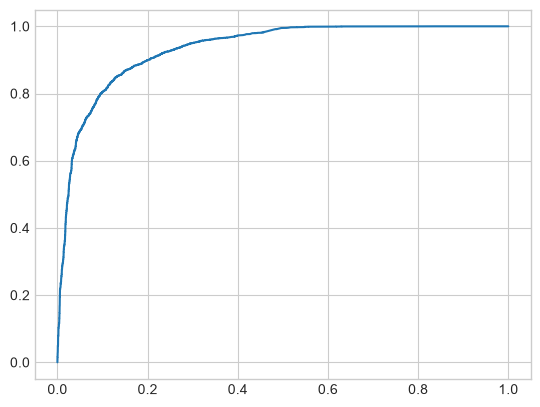

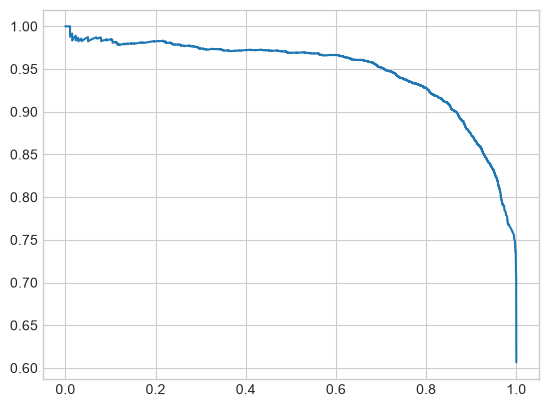

In [15]:
# TODO: Optimizar umbral y graficar métricas en Test
# === ESCRIBE TU CÓDIGO AQUÍ ===
y_proba_test = best_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.91, 0.1)
f1_scores = []

for t in thresholds:
    y_pred = (y_proba_test >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred))

best_thresh = thresholds[np.argmax(f1_scores)]

print(f"Threshold: {best_thresh:.2f} | F1: {f1_score(y_test, y_pred):.4f} | AUC: {roc_auc_score(y_test, y_proba_test):.4f}")

sns.heatmap(confusion_matrix(y_test, y_pred), annot = True, fmt = "d")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba_test)
plt.plot(fpr, tpr)
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_proba_test)
plt.plot(recall, precision)
plt.show()